In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
model =init_chat_model("groq:qwen/qwen3-32b")

In [2]:
model.invoke("hi")

AIMessage(content='<think>\nOkay, the user said "hi". That\'s pretty straightforward. They probably want to start a conversation. I should respond in a friendly and welcoming way. Let me make sure my tone is positive. Maybe say hello back and ask how I can help them today. Keep it open-ended so they can specify their needs. I need to check if there\'s any specific context, but since it\'s just "hi", there\'s not much else. Alright, time to craft a simple and helpful response.\n</think>\n\nHello! How can I assist you today? If you have any questions or need help with something, feel free to let me know! 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 9, 'total_tokens': 143, 'completion_time': 0.338602928, 'completion_tokens_details': None, 'prompt_time': 0.000331725, 'prompt_tokens_details': None, 'queue_time': 0.082569725, 'total_time': 0.338934653}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_5cf921caa2', 'service_t

In [3]:
def multiply(a:int,b:int)->int:
    """Multiply a and b
        Args:
            a: first int
            b: second int
    """
    return a*b

def add(a:int,b:int)->int:
    """add a and b
        Args:
            a: first int
            b: second int
    """
    return a + b

def division(a:int,b:int)->int:
    """division a and b
        Args:
            a: first int
            b: second int
    """
    return a/b

In [4]:
tools = [add,multiply,division]
tools

[<function __main__.add(a: int, b: int) -> int>,
 <function __main__.multiply(a: int, b: int) -> int>,
 <function __main__.division(a: int, b: int) -> int>]

In [5]:
## Integrate custom tool
model_with_tools = model.bind_tools(tools)
model_with_tools

RunnableBinding(bound=ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001DE092C8A50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001DE0942E110>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'add a and b\nArgs:\n    a: first int\n    b: second int', 'parameters': {'properties': {'a': {'type': 'integer'}, 'b': {'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b\nArgs:\n    a: first int\n    b: second int', 'parameters': {'properties': {'a': {'type': 'integ

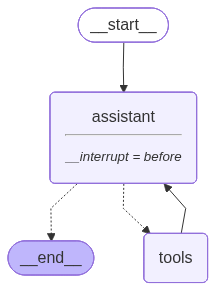

In [6]:
### Work flow with langgraph

from IPython.display import Image,display
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START,StateGraph
from langgraph.prebuilt import tools_condition,ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

## System message

sys_msg = SystemMessage(content="You are a helpful assistant talked with performing arthematic on a set of inputs.")

## node definition
def assistant(state:MessagesState):
    return {"messages": [model_with_tools.invoke([sys_msg] + state["messages"])]}

## graph
builder = StateGraph(MessagesState)

builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    ## if latest message is a tool call it will go to toolnode else it will go to END
    tools_condition
)
builder.add_edge("tools","assistant")
memory = MemorySaver()

## Human in Loop
graph = builder.compile(interrupt_before=["assistant"],checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [7]:
thread = {"configurable":{"thread_id":"123"}}
initial_input = {"messages":HumanMessage(content="multiply 2 and 3")}

In [8]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

multiply 2 and 3


In [9]:
state = graph.get_state(thread)
state.next

('assistant',)

In [10]:
state

StateSnapshot(values={'messages': [HumanMessage(content='multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='110fbdfd-97b5-4d2b-9216-489b4667dba8')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f11e9f2-7b3b-6d0c-8000-c47af256340f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-13T05:40:33.992014+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f11e9f2-7b2c-6b8f-bfff-0fa0d1fbe5a0'}}, tasks=(PregelTask(id='8028c965-c4d6-c65d-a3c2-0b203695b2c3', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())